<a href="https://colab.research.google.com/github/unidari/ml/blob/main/ml_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Ансамблевые методы в машинном обучении**

## **Задание №1: Классификация лиц из набора данных Olivetti Faces с помощью алгоритмов градиентного бустинга**

В этом задании мы применим несколько популярных алгоритмов градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoosting из библиотеки scikit-learn для решения задачи классификации лиц из набора данных Olivetti Faces. Цель - определить, какому человеку принадлежит новое изображение лица, на основе обучения на размеченных данных.





Шаги выполнения задания:

1. Загрузите набор данных Olivetti Faces с помощью функции `fetch_olivetti_faces()` из scikit-learn.

2. Разделите данные на обучающую и тестовую выборки с помощью `train_test_split()`.

3. Выполните предобработку изображений:
   - Преобразуйте изображения в вектора признаков (flatten)
   - Нормализуйте значения пикселей (разделите на 255)

4. Создайте и обучите модели градиентного бустинга:
   - CatBoostClassifier
   - LGBMClassifier
   - XGBClassifier
   - GradientBoostingClassifier

5. Оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

6. Сравните точность и время обучения разных алгоритмов. Определите, какой из них лучше подходит для данной задачи.

7. Сделайте выводы о сравнительной эффективности разных алгоритмов градиентного бустинга для классификации лиц.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

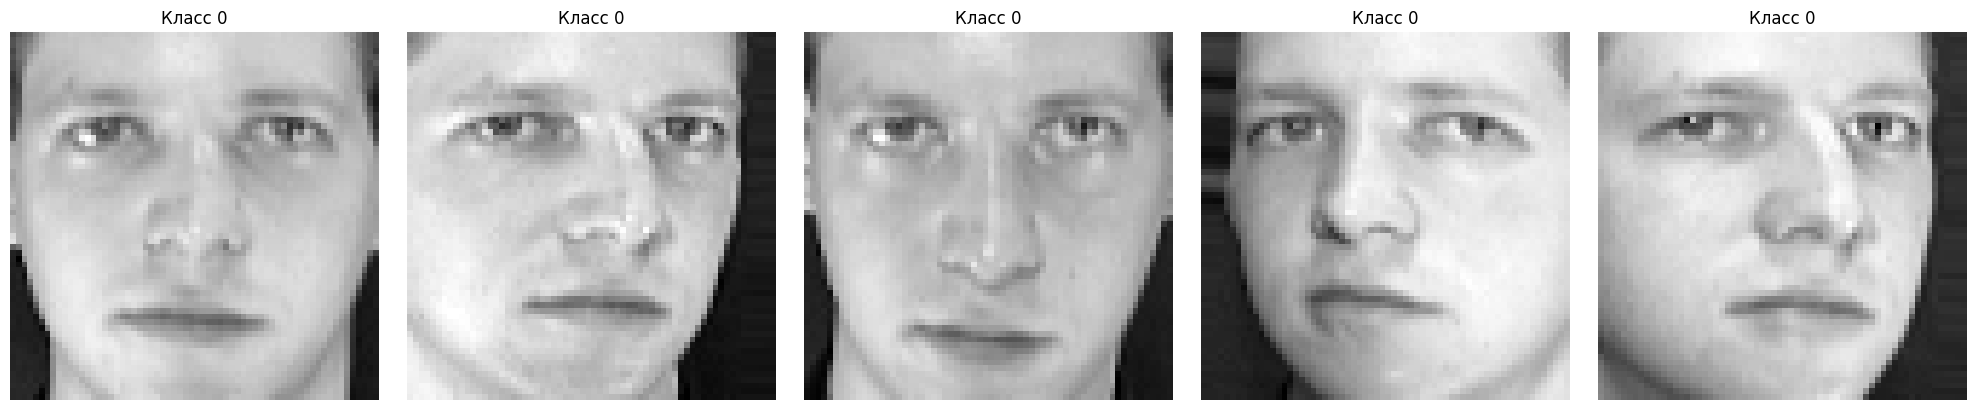

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = faces.data
y = faces.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, y_train.shape)

X = X / 255.0

(280, 4096) (280,)


In [ ]:
import time

from catboost import CatBoostClassifier, Pool
import lightgbm as Lgb
import xgboost as Xg
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score

In [ ]:
results = {}

start_time_Gb = time.time()

Gb = GradientBoostingClassifier(n_estimators=10, learning_rate=0.1,
                                max_depth=3, random_state=42)
Gb.fit(X_train, y_train)
training_time_Gb = time.time() - start_time_Gb

y_pred_Gb = Gb.predict(X_test)
accuracy_Gb = accuracy_score(y_test, y_pred_Gb)

results['GradientBoostingClassifier'] = {
    'accuracy': accuracy_Gb,
    'training_time': training_time_Gb
    }

print(f"Точность модели - GradientBoostingClassifier - {accuracy_Gb:.4f}")
print(f"Время обучения - GradientBoostingClassifier - {training_time_Gb:.4f}")

Точность модели - GradientBoostingClassifier - 0.5167
Время обучения - GradientBoostingClassifier - 169.6816


In [ ]:
train_pool = Pool(X_train, y_train)
test_pool = Pool(X_test, y_test)

Cat = CatBoostClassifier(
    iterations=50,
    learning_rate=0.1,
    depth=5,
    verbose=0,
    random_seed=42
)

start_time_Сat = time.time()
Cat.fit(train_pool)
training_time_Cat = time.time() - start_time_Сat

y_pred_Cat = Cat.predict(test_pool)
accuracy_Cat = accuracy_score(y_test, y_pred_Cat)
results['CatBoost'] = {
    'accuracy': accuracy_Cat,
    'training_time': training_time_Cat
    }

print(f"Точность модели - CatBoostClassifier - {accuracy_Cat:.4f}")
print(f"Время обучения - CatBoostClassifier - {training_time_Cat:.4f}")

Точность модели - CatBoostClassifier - 0.7167
Время обучения - CatBoostClassifier - 313.1942


In [ ]:
train_Data = Lgb.Dataset(X_train, label=y_train)
test_Data = Lgb.Dataset(X_test, label=y_test, reference=train_Data)

params = {'objective': 'multiclass', 'num_class':40,
          'metric': 'multi_logloss', 'learning_rate': 0.1, 'num_leaves': 31, 'verbose': -1}
num_round = 100

start_time_Lgb = time.time()
lgb = Lgb.train(params, train_Data, num_round, valid_sets=[test_Data])
training_time_Lgb = time.time() - start_time_Lgb

y_pred_Lgb = np.argmax((lgb.predict(X_test, num_iteration=lgb.best_iteration) > 0.5).astype(int), axis=1)
accuracy_lgb = accuracy_score(y_test, y_pred_Lgb)
results['LightGBM'] = {
    'accuracy': accuracy_lgb,
    'training_time': training_time_Lgb}

print(f"Точность модели - LGBMClassifier - {accuracy_lgb:.4f}")
print(f"Время обучения - LGBMClassifier - {training_time_Lgb:.4f}")

Точность модели - LGBMClassifier - 0.7250
Время обучения - LGBMClassifier - 100.2633


In [ ]:
train_DM = Xg.DMatrix(X_train, label=y_train)
test_DM = Xg.DMatrix(X_test, label=y_test)
params = {
    'objective': 'multi:softmax',
    'num_class': 40,
    'eta': 0.1,
    'max_depth': 5,
    'random_state' : 42
}
num_rounds = 100

start_time_Xgb = time.time()
model = Xg.train(params, train_DM, num_rounds)
training_time_Xgb = time.time() - start_time_Xgb

y_pred_Xgb = model.predict(test_DM).astype(int)
y_pred_Xgb = y_pred_Xgb.astype(int)
accuracy_Xgb = accuracy_score(y_test, y_pred_Xgb)
results['XGBoost'] = {
    'accuracy': accuracy_Xgb,
    'training_time': training_time_Xgb
    }

print(f"Точность модели - XGBoost - {accuracy_Xgb:.4f}")
print(f"Время обучения - XGBoost - {training_time_Xgb:.4f}")

Точность модели - XGBoost - 0.7250
Время обучения - XGBoost - 127.3966


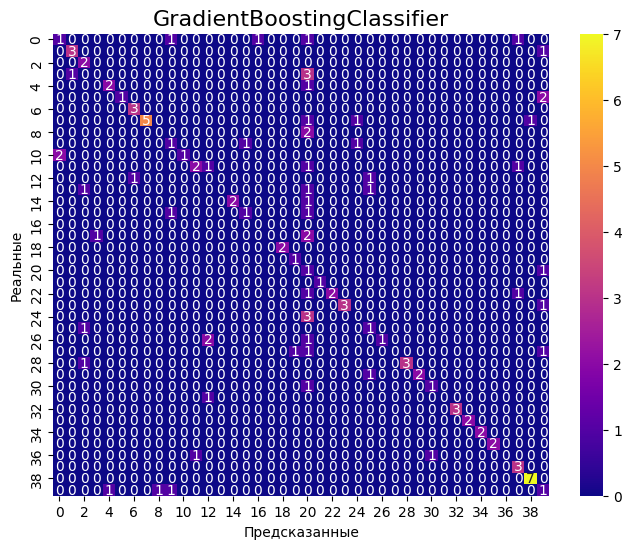

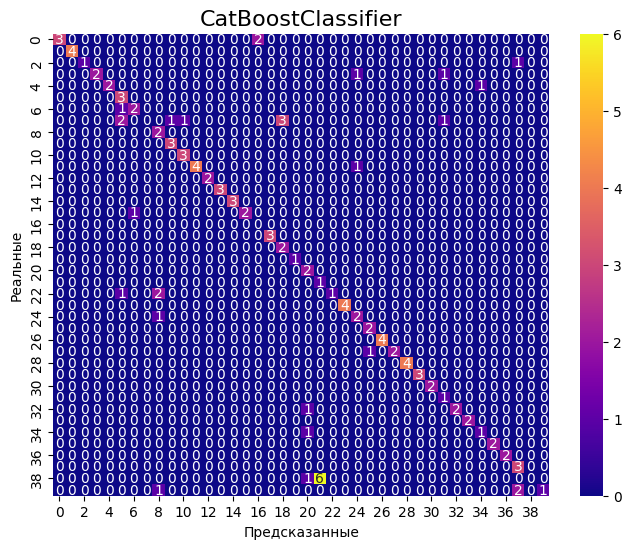

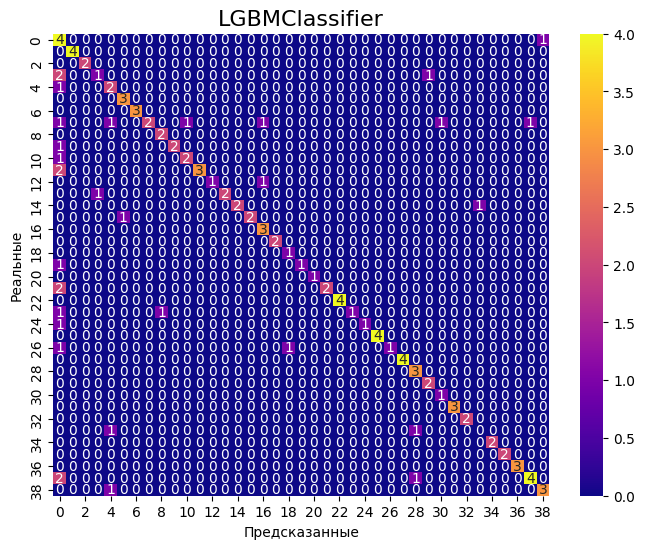

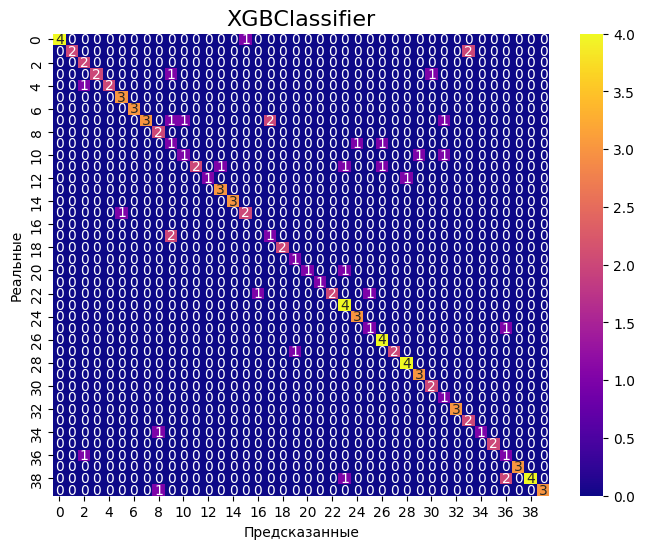

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

predictions = {}

predictions['GradientBoostingClassifier'] = {'pred': y_pred_Gb}
predictions['CatBoostClassifier'] = {'pred': y_pred_Cat}
predictions['LGBMClassifier'] = {'pred': y_pred_Lgb}
predictions['XGBClassifier'] = {'pred': y_pred_Xgb}

models = list(predictions.keys())

for model in models:
  cm = confusion_matrix(y_test, predictions[model]['pred'])
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm,
              annot=True,
              fmt=".0f",
              cmap='plasma')

  plt.title(str(model), fontsize=16)
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()

In [ ]:
for model_name, data in predictions.items():

    print(model_name)
    print(classification_report(y_test, data['pred']))

GradientBoostingClassifier
              precision    recall  f1-score   support

           0       0.33      0.20      0.25         5
           1       0.75      0.75      0.75         4
           2       0.40      1.00      0.57         2
           3       0.00      0.00      0.00         4
           4       0.67      0.67      0.67         3
           5       1.00      0.33      0.50         3
           6       0.75      1.00      0.86         3
           7       1.00      0.62      0.77         8
           8       0.00      0.00      0.00         2
           9       0.25      0.33      0.29         3
          10       1.00      0.33      0.50         3
          11       0.67      0.40      0.50         5
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         3
          14       1.00      0.67      0.80         3
          15       0.50      0.33      0.40         3
          16       0.00      0.00      0.00         0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

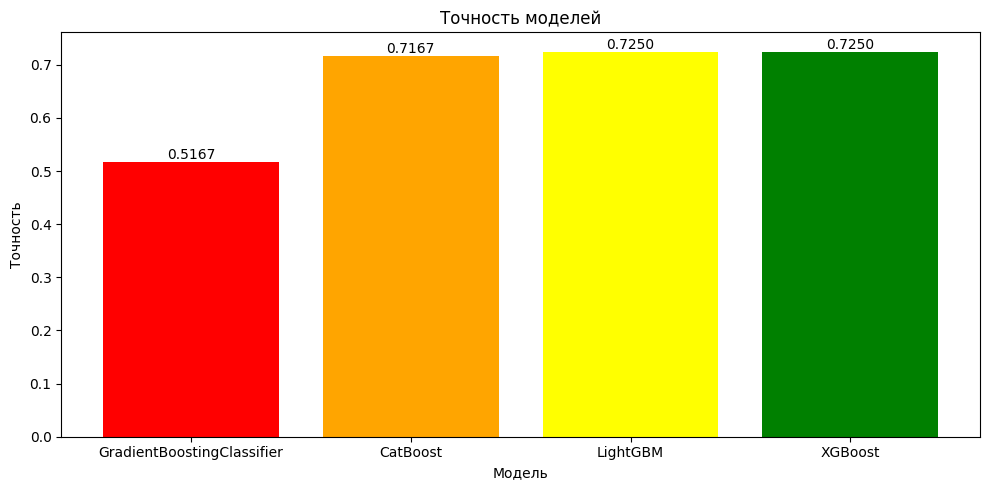

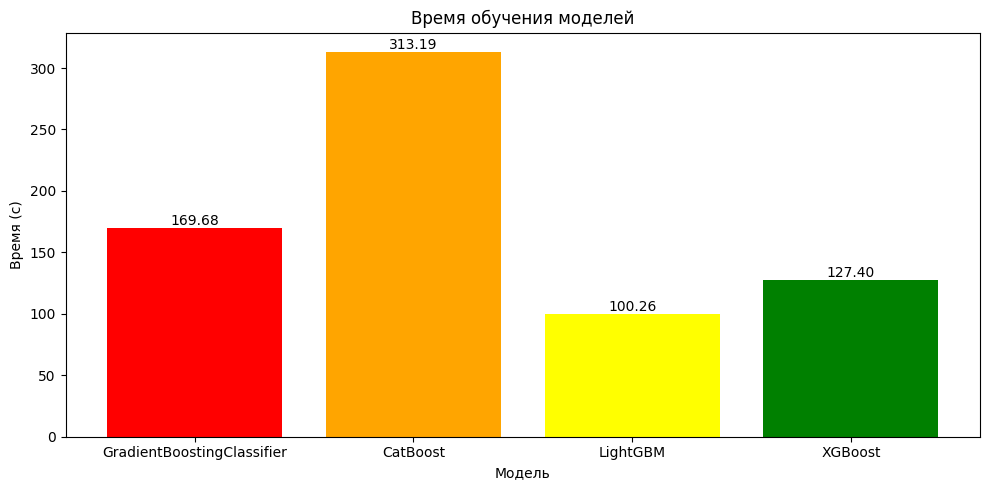

In [ ]:
import numpy as np

models = list(results.keys())
accuracies = [results[model]['accuracy'] for model in models]
training_times = [results[model]['training_time'] for model in models]

colors = ['red', 'orange', 'yellow', 'green']

plt.figure(figsize=(10, 5))

bars = plt.bar(models, accuracies, color=colors)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{accuracies[i]:.4f}', ha='center', va='bottom')
plt.title('Точность моделей')
plt.xlabel('Модель')
plt.ylabel('Точность')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

bars = plt.bar(models, training_times, color=colors)
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{training_times[i]:.2f}', ha='center', va='bottom')
plt.title('Время обучения моделей')
plt.xlabel('Модель')
plt.ylabel('Время (с)')
plt.tight_layout()
plt.show()

## **Задание №2: Предсказание нижней половины лица по верхней с помощью алгоритмов градиентного бустинга**




- В этом задании мы применим алгоритмы градиентного бустинга - CatBoost, LightGBM, XGBoost и GradientBoostingRegressor - для решения интересной задачи регрессии на датасете лиц Olivetti Faces. Цель - предсказать значения пикселей нижней половины лица по пикселям верхней половины.

- Каждое изображение лица представляет собой матрицу 64x64 в оттенках серого. Мы разделим изображения на верхнюю и нижнюю половины и будем предсказывать значения яркости пикселей нижней половины по значениям верхней.

- Сравним качество (по метрике R^2) и время обучения разных реализаций градиентного бустинга на этой задаче восстановления изображений. Посмотрим, насколько хорошо алгоритмы бустинга смогут достроить нижнюю часть лица по верхней.

Датасет: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_olivetti_faces.html

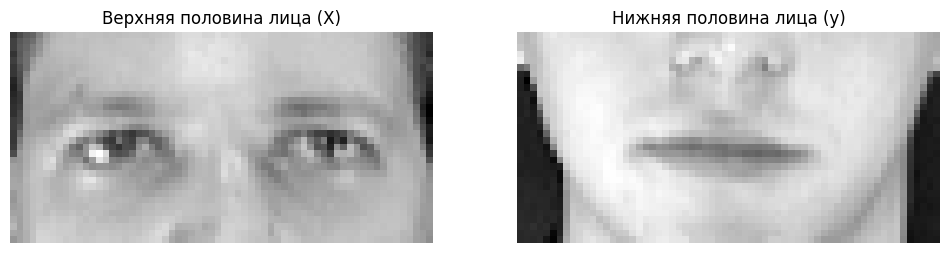

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
n_samples = images.shape[0]

# Разделение изображений на верхнюю и нижнюю половины
upper_half = images[:, :32, :]  # Верхняя половина (первые 32 строки)
lower_half = images[:, 32:, :]  # Нижняя половина (последние 32 строки)

# Преобразование 2D изображений в 1D векторы
X = upper_half.reshape((n_samples, -1))
y = lower_half.reshape((n_samples, -1))

# Выбор одного примера для отображения
sample_index = 0  # Измените значение для выбора другого изображения

# Восстановление изображений из векторов
upper_face = X[sample_index].reshape(32, 64)
lower_face = y[sample_index].reshape(32, 64)

# Отображение верхней и нижней половин лица
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(upper_face, cmap='gray')
axes[0].set_title('Верхняя половина лица (X)')
axes[0].axis('off')

axes[1].imshow(lower_face, cmap='gray')
axes[1].set_title('Нижняя половина лица (y)')
axes[1].axis('off')

plt.show()

In [ ]:
import time
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
import lightgbm as Lgb
import xgboost as Xgb
from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)
X_train.shape, X_test.shape

results = {}
pred_test = {}

start_time = time.time()
GB2 = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=15,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    n_jobs=-1
)
GB2.fit(X_train, y_train)
training_time_GB2 = time.time() - start_time

y_pred_GB2 = GB2.predict(X_test)
pred_test['GradientBoostingRegressor'] = y_pred_GB2

R2_GB2 = r2_score(y_test, y_pred_GB2, multioutput='uniform_average')

results['GradientBoostingRegressor'] = {'R2': R2_GB2,
                                        'training_time': training_time_GB2}
print(f"R2 - {R2_GB2:.4f} - time - {training_time_GB2:.2f} (GradientBoostingRegressor)")

R2 - 0.4683 - time - 4553.90 (GradientBoostingRegressor)


In [ ]:
start_time = time.time()
Cat = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=15,
        learning_rate=0.1,
        depth=3,
        random_seed=42,
        verbose=False,
        thread_count=-1
    ),
    n_jobs=-1
)

Cat.fit(X_train, y_train)
training_time_Cat = time.time() - start_time

y_pred_Cat = Cat.predict(X_test)
pred_test['CatBoost'] = y_pred_Cat
R2_Cat = r2_score(y_test, y_pred_Cat, multioutput='uniform_average')

results['CatBoost'] = {'R2': R2_Cat,
                       'training_time': training_time_Cat}

print(f"R2 - {R2_Cat:.4f} - time - {training_time_Cat:.2f} (CatBoostRegressor)")

R2 - 0.3795 - time - 2250.83 (CatBoostRegressor)


In [ ]:
start_time = time.time()
lgb = MultiOutputRegressor(
    Lgb.LGBMRegressor(
        n_estimators=15,
        learning_rate=0.1,
        max_depth=3,
        num_leaves=8,
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ),
    n_jobs=-1
)

lgb.fit(X_train, y_train)
training_time_Lgb = time.time() - start_time

y_pred_Lgb = lgb.predict(X_test)
pred_test['LightGBM'] = y_pred_Lgb

R2_Lgb = r2_score(y_test, y_pred_Lgb, multioutput='uniform_average')

results['LightGBM'] = {'R2': R2_Lgb,
                       'training_time': training_time_Lgb}

print(f"R2 - {R2_Lgb:.4f} - time - {training_time_Lgb:.2f} (LGBMRegressor)")

R2 - 0.4673 - time - 1222.53 (LGBMRegressor)


In [ ]:
start_time = time.time()
xgb = MultiOutputRegressor(
    Xgb.XGBRegressor(
        n_estimators=15,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    ),
    n_jobs=-1
)

xgb.fit(X_train, y_train)
training_time_Xgb = time.time() - start_time

y_pred_Xgb = xgb.predict(X_test)
pred_test['XGBoost'] = y_pred_Xgb
R2_Xgb = r2_score(y_test, y_pred_Xgb, multioutput='uniform_average')

results['XGBoost'] = {'R2': R2_Xgb,
                      'training_time': training_time_Xgb}

print(f"R2 - {R2_Xgb:.4f} - time - {training_time_Xgb:.2f} (XGBRegressor)")

R2 - 0.4627 - time - 1665.20 (XGBRegressor)


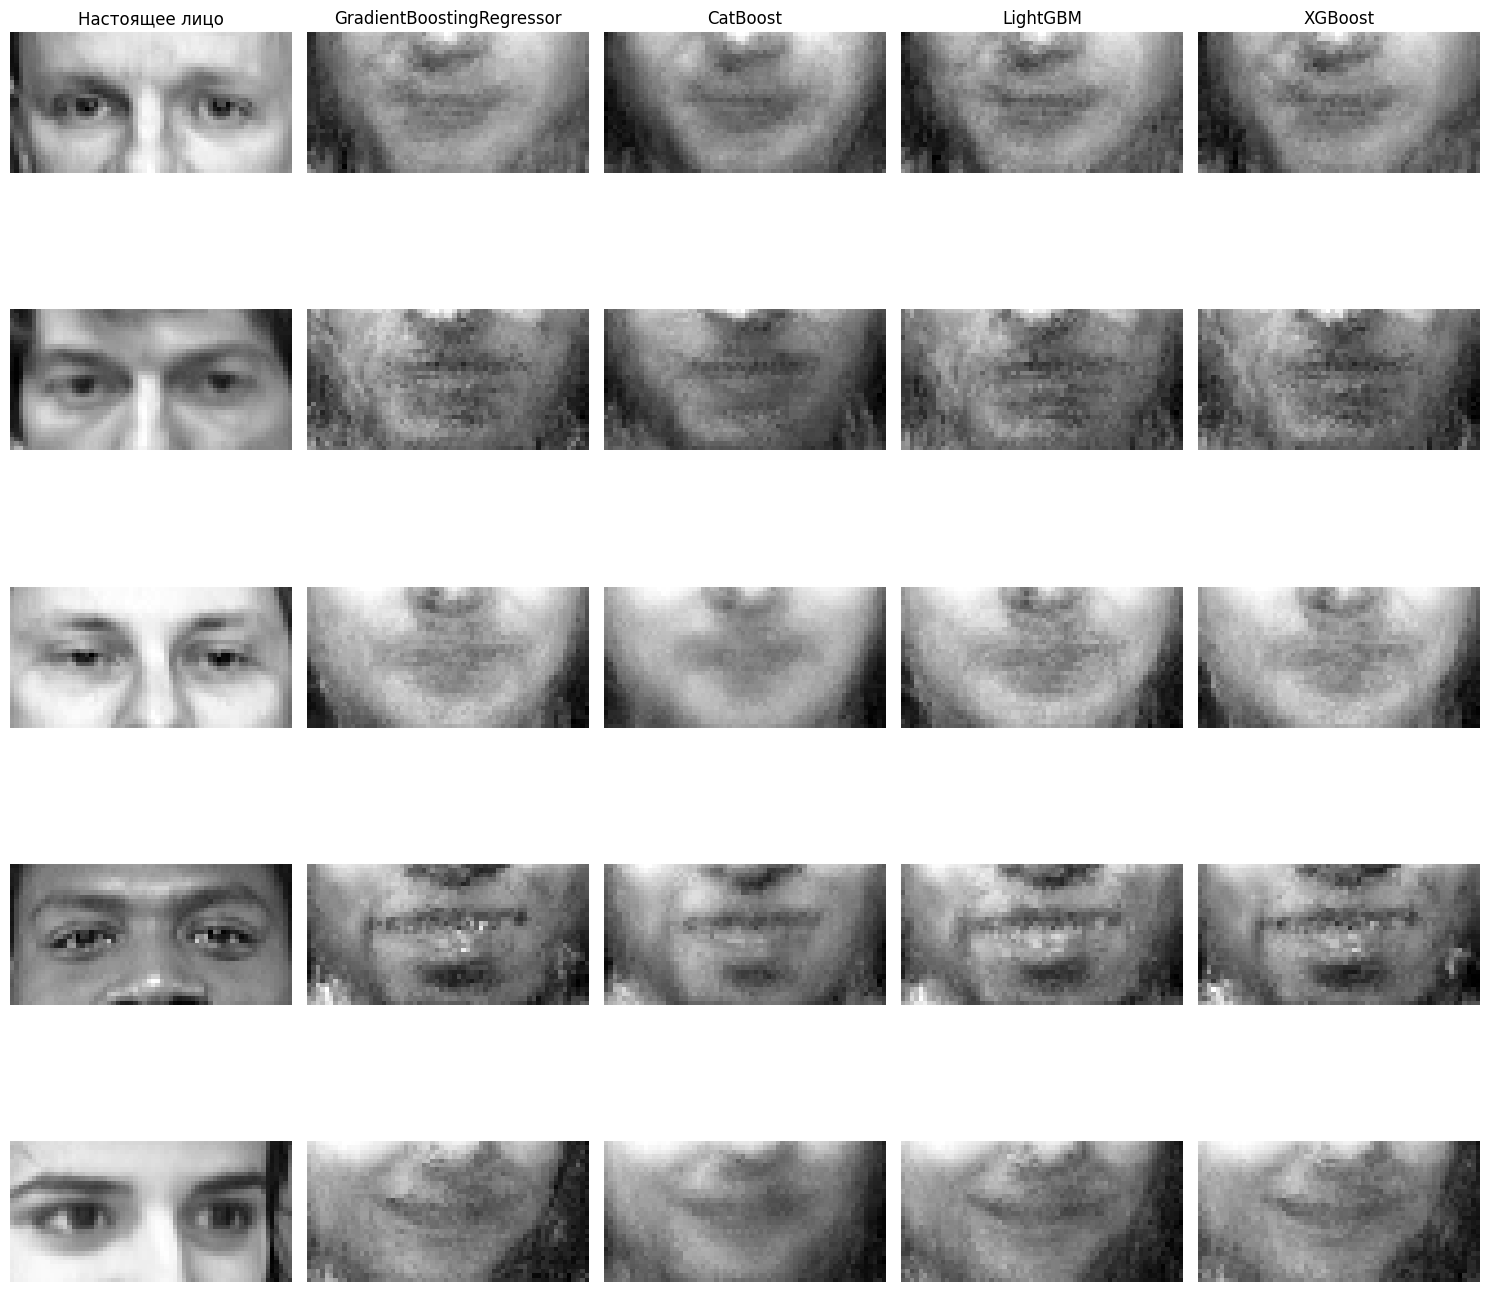

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def auto_shape(vector_size):
    best_h, best_w = None, None
    best_diff = float('inf')
    for h in range(1, int(np.sqrt(vector_size)) + 1):
        if vector_size % h == 0:
            w = vector_size // h
            diff = abs(h - w)
            if diff < best_diff:
                best_diff = diff
                best_h, best_w = h, w
    if best_h > best_w:
        best_h, best_w = best_w, best_h
    return best_h, best_w

sample_size = X_test[0].size
height, width = auto_shape(sample_size)

model_names = ['GradientBoostingRegressor', 'CatBoost', 'LightGBM', 'XGBoost']
faces = 5
cols = 5
fig, axes = plt.subplots(faces, cols, figsize=(3 * cols, 3 * faces))

for i in range(faces):
    ax_true = axes[i, 0]
    ax_true.imshow(X_test[i].reshape(height, width), cmap='gray', interpolation='nearest')
    ax_true.set_title("Настоящее лицо" if i == 0 else "")
    ax_true.set_xlabel(f"Класс {y_test[i]}")
    ax_true.axis('off')

    for j, model in enumerate(model_names):
        ax = axes[i, j + 1]
        pred = pred_test[model]

        if pred.ndim == 1 or (pred.ndim == 2 and pred.shape[1] == 1):
            pred_class = pred[i] if pred.ndim == 1 else pred[i, 0]
            ax.text(0.5, 0.5, str(pred_class), ha='center', va='center', fontsize=12)
        else:
            ax.imshow(pred[i].reshape(height, width), cmap='gray', interpolation='nearest')

        ax.set_title(model if i == 0 else "")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

for name, pred in pred_test.items():
    if y_test.shape != pred.shape:
        r2 = r2_score(y_test.reshape(-1, 1), pred)
    else: r2 = r2_score(y_test, pred)
    print(f"R2 score ({name}): {r2:.4f}")

R2 score (GradientBoostingRegressor): 0.4683
R2 score (CatBoost): 0.3795
R2 score (LightGBM): 0.4673
R2 score (XGBoost): 0.4627


## **Задание №3: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов VotingClassifier**



- В этом задании мы применим ансамблевый метод классификации VotingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. VotingClassifier объединяет предсказания нескольких базовых классификаторов путем голосования, что позволяет улучшить качество классификации по сравнению с отдельными моделями

- Мы будем использовать несколько "слабых" классификаторов, таких как LogisticRegression, DecisionTreeClassifier и KNeighborsClassifier, NaiveBayes и объединим их в ансамбль с помощью VotingClassifier. Затем сравним точность ансамбля с отдельными базовыми моделями и оценим эффект от их комбинирования.



- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

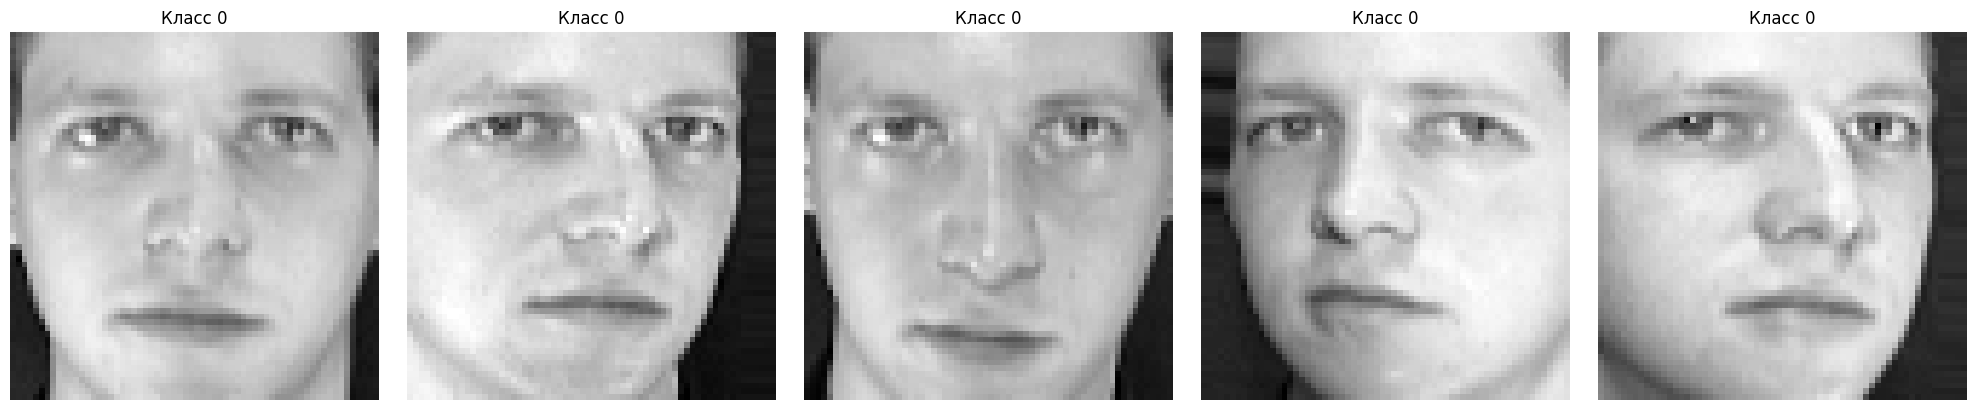

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)
print(X_train.shape, X_test.shape)

Lr = LogisticRegression(max_iter=100, random_state=42)
Knn = KNeighborsClassifier(n_neighbors=5)
Dt = DecisionTreeClassifier(random_state=42)
Nb = GaussianNB()
Lr.fit(X_train, y_train)
Knn.fit(X_train, y_train)
Dt.fit(X_train, y_train)
Nb.fit(X_train, y_train)

voting_clf = VotingClassifier(
    estimators=[('Lr', Lr), ('Knn', Knn), ('Dt', Dt), ('Nb', Nb)],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

(280, 4096) (120, 4096)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

VotingClassifier(estimators=[('Lr', LogisticRegression(random_state=42)),
                             ('Knn', KNeighborsClassifier()),
                             ('Dt', DecisionTreeClassifier(random_state=42)),
                             ('Nb', GaussianNB())],
                 voting='soft')

In [ ]:
print('Точность')

y_pred_Lr = Lr.predict(X_test)
acc_Lr = accuracy_score(y_test, y_pred_Lr)
print(f'LogisticalRegression: {acc_Lr}')

y_pred_Knn = Knn.predict(X_test)
acc_Knn = accuracy_score(y_test, y_pred_Knn)
print(f'KNN: {acc_Knn}')

y_pred_Dt = Dt.predict(X_test)
acc_Dt = accuracy_score(y_test, y_pred_Dt)
print(f'DecisionTree: {acc_Dt}')

y_pred_Nb = Nb.predict(X_test)
acc_Nb = accuracy_score(y_test, y_pred_Nb)
print(f'NaiveBayes: {acc_Nb}')

y_pred_ensemble = voting_clf.predict(X_test)
acc_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Ансамбль: {acc_ensemble:.2f}')

Точность
LogisticalRegression: 0.95
KNN: 0.7833333333333333
DecisionTree: 0.5333333333333333
NaiveBayes: 0.7416666666666667
Ансамбль: 0.88


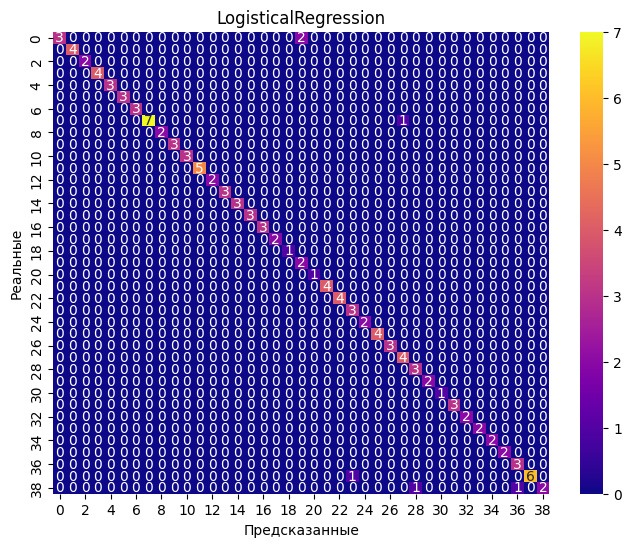

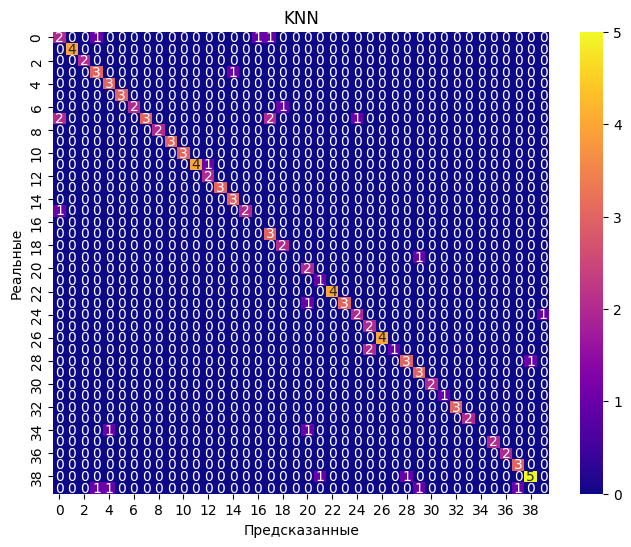

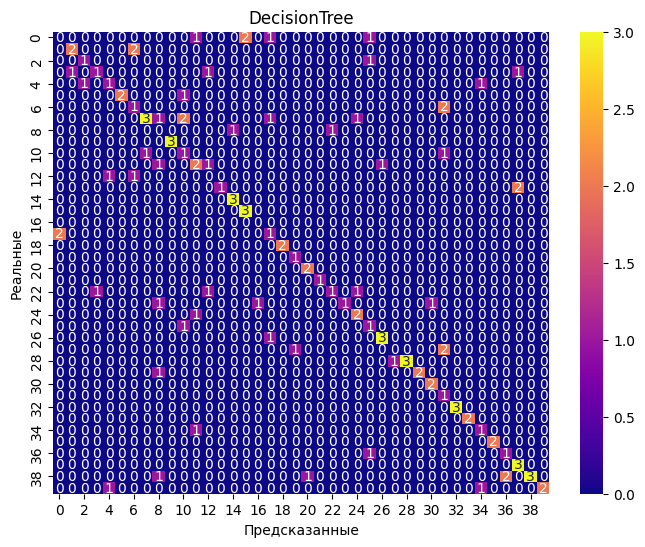

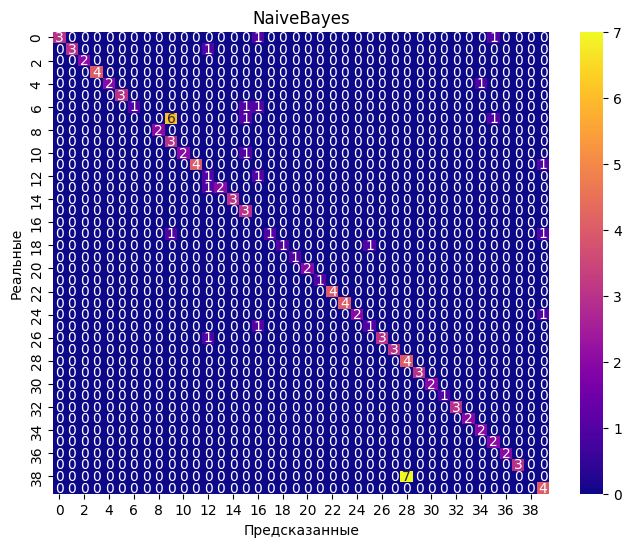

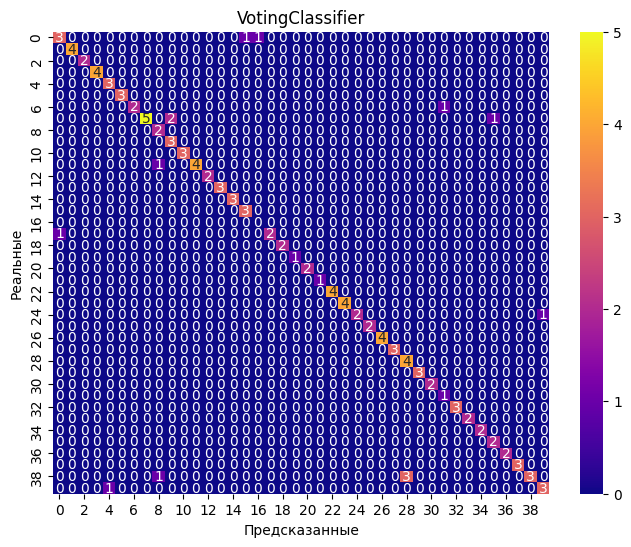

              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3
           7       1.00      0.62      0.77         8
           8       0.50      1.00      0.67         2
           9       0.60      1.00      0.75         3
          10       1.00      1.00      1.00         3
          11       1.00      0.80      0.89         5
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         3
          14       1.00      1.00      1.00         3
          15       0.75      1.00      0.86         3
          16       0.00      0.00      0.00         0
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions2 = {}

predictions2['LogisticalRegression'] = {'pred': y_pred_Lr}
predictions2['KNN'] = {'pred': y_pred_Knn}
predictions2['DecisionTree'] = {'pred': y_pred_Dt}
predictions2['NaiveBayes'] = {'pred': y_pred_Nb}
predictions2['VotingClassifier'] = {'pred': y_pred_ensemble}

models2 = list(predictions2.keys())
for model in models2:
  cm = confusion_matrix(y_test, predictions2[model]['pred'])
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm,
              annot=True,
              fmt=".0f",
              cmap='plasma')

  plt.title(model)
  plt.xlabel('Предсказанные')
  plt.ylabel('Реальные')
  plt.show()

print(classification_report(y_test, y_pred_ensemble))

/tmp/ipykernel_37512/1196516951.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Модель', y='Точность', palette='plasma')


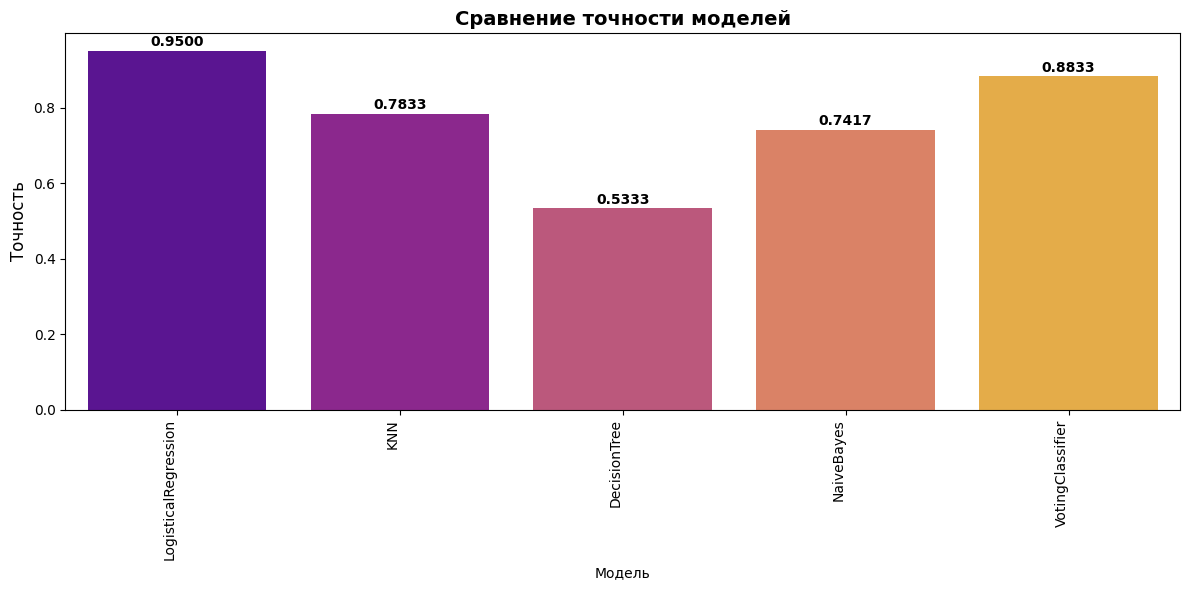

In [ ]:
import seaborn as sns
import pandas as pd

models = ['LogisticalRegression', 'KNN',
          'DecisionTree', 'NaiveBayes', 'VotingClassifier']
accuracies = [acc_Lr, acc_Knn, acc_Dt, acc_Nb, acc_ensemble]

df = pd.DataFrame({'Модель': models, 'Точность': accuracies})

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Модель', y='Точность', palette='plasma')
plt.title('Сравнение точности моделей', fontsize=14, fontweight='bold')
plt.ylabel('Точность', fontsize=12)
plt.xticks(rotation=90, ha='right')

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## **Задание №4: Классификация лиц из набора Olivetti Faces с помощью ансамбля классификаторов** [**StackingClassifier**](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html)



- В этом задании мы применим ансамблевый метод классификации StackingClassifier из библиотеки scikit-learn для решения задачи распознавания лиц из набора данных Olivetti Faces. StackingClassifier объединяет предсказания нескольких базовых классификаторов путем обучения метаклассификатора на их выходах, что позволяет улучшить качество классификации по сравнению с отдельными моделями и методом голосования VotingClassifier.


- Мы будем использовать несколько "слабых" классификаторов первого уровня, таких как LogisticRegression, DecisionTreeClassifier, KNeighborsClassifier и GaussianNB. Затем мы обучим метаклассификатор второго уровня (например, LogisticRegression или SVC) на выходах классификаторов первого уровня. Метаклассификатор будет учиться комбинировать предсказания базовых моделей оптимальным образом.




- Не забудьте предварительно обработать изображения перед подачей в модели:
  - Преобразовать изображения в вектора признаков (flatten)
  - Нормализовать значения пикселей (разделить на 255)

- После обучения, оцените качество классификации каждой модели на тестовой выборке, используя метрику accuracy, отчет классификации и построение матрицы ошибок.

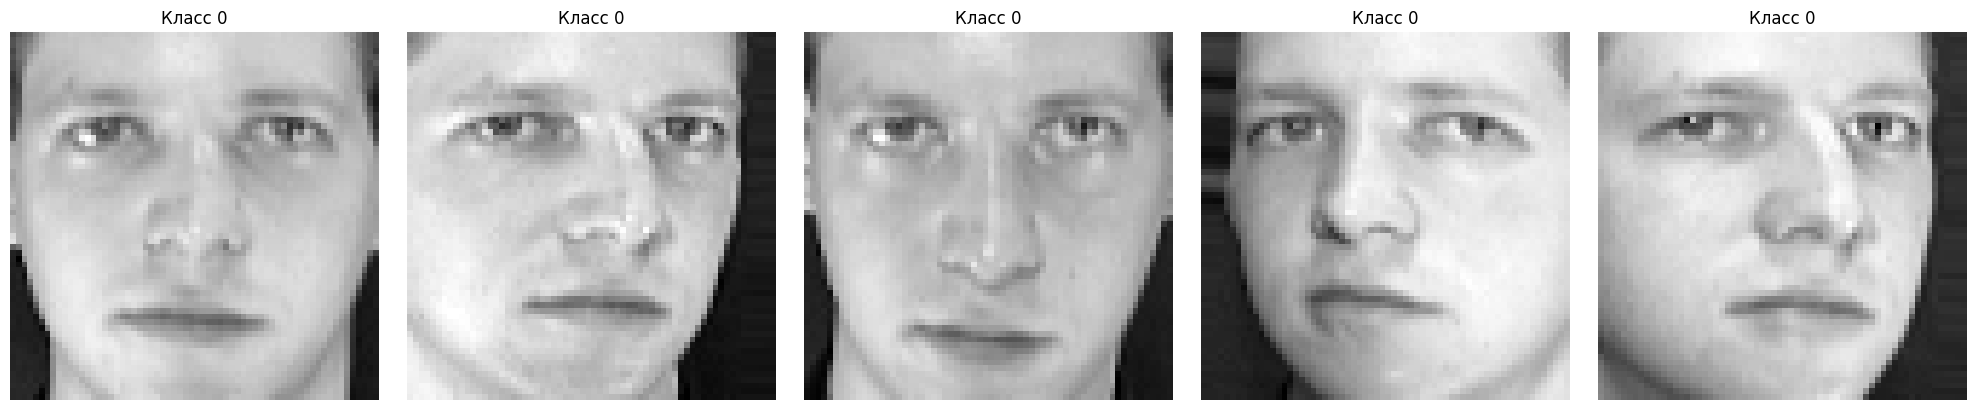

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Загрузка датасета
faces = fetch_olivetti_faces()
images = faces.images  # Изображения размером 64x64
labels = faces.target  # Метки классов (номера людей)

# Отображение первых пяти изображений и их классов
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i in range(5):
    image = images[i]
    label = labels[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f'Класс {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_olivetti_faces
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, accuracy_score


X, y = fetch_olivetti_faces(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
print(X_train.shape, X_test.shape)

Lr = LogisticRegression(max_iter=100, random_state=42)
Knn = KNeighborsClassifier(n_neighbors=5)
Dt = DecisionTreeClassifier(random_state=42)
Nb = GaussianNB()
Lr.fit(X_train, y_train)
Knn.fit(X_train, y_train)
Dt.fit(X_train, y_train)
Nb.fit(X_train, y_train)

stacking_clf = StackingClassifier(
    estimators=[('Lr', Lr), ('Knn', Knn), ('Dt', Dt), ('Nb', Nb)],
    final_estimator=LogisticRegression(max_iter=100, random_state=42),
    cv=KFold(n_splits=5, shuffle=True, random_state=42)
)
stacking_clf.fit(X_train, y_train)
stacking_pred = stacking_clf.predict(X_test)
acc_stacking = accuracy_score(y_test, stacking_pred)
print(f"Accuracy: {acc_stacking:.2f}")
print(classification_report(y_test, stacking_pred))

(320, 4096) (80, 4096)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy: 0.94
              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.67      0.80         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       1.00      0.50      0.67         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       0.00      0.00      0.00         0
          17       1.00      1.00      1.00         3
          18

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Модель: LogisticRegression
Accuracy: 0.96
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          17       1.00      1.00      1.00         3
          18       1.00      1.00      

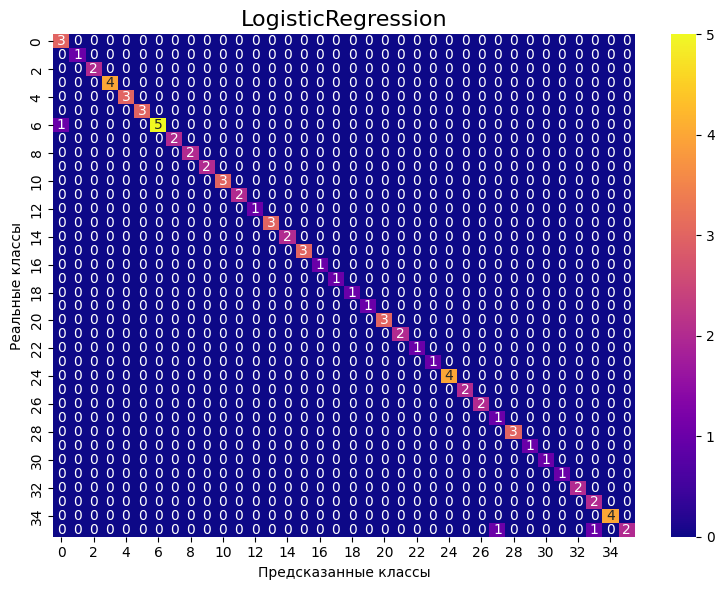

Модель: KNN
Accuracy: 0.86
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       0.75      0.75      0.75         4
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           7       1.00      0.83      0.91         6
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      0.67      0.80         3
          12       0.67      1.00      0.80         2
          13       1.00      1.00      1.00         1
          14       0.75      1.00      0.86         3
          15       1.00      0.50      0.67         2
          17       0.75      1.00      0.86         3
          18       1.00      1.00      1.00         1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


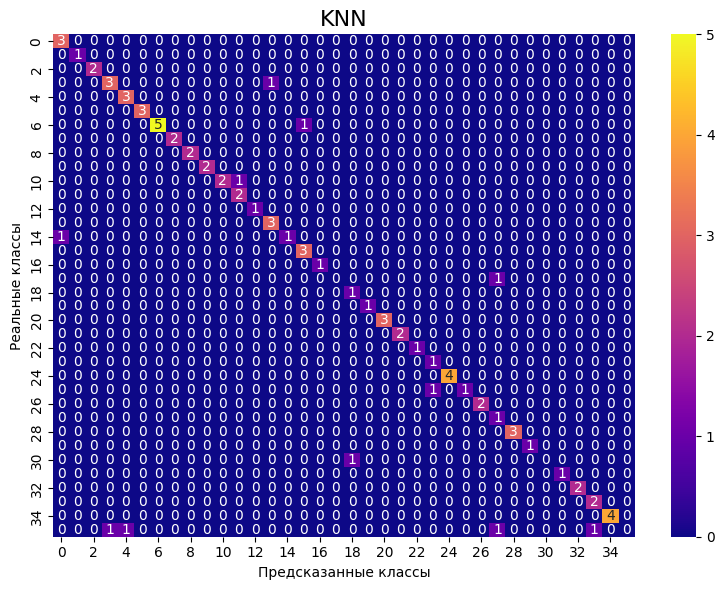

Модель: DecisionTreeClassifier
Accuracy: 0.49
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       1.00      1.00      1.00         1
           2       0.33      0.50      0.40         2
           3       0.50      0.50      0.50         4
           4       0.50      0.33      0.40         3
           5       1.00      0.67      0.80         3
           7       1.00      0.17      0.29         6
           8       0.50      0.50      0.50         2
           9       0.50      0.50      0.50         2
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         1
          14       0.67      0.67      0.67         3
          15       0.33      0.50      0.40         2
          16       0.00      0.00      0.00         0
          17       0.67      0.67  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

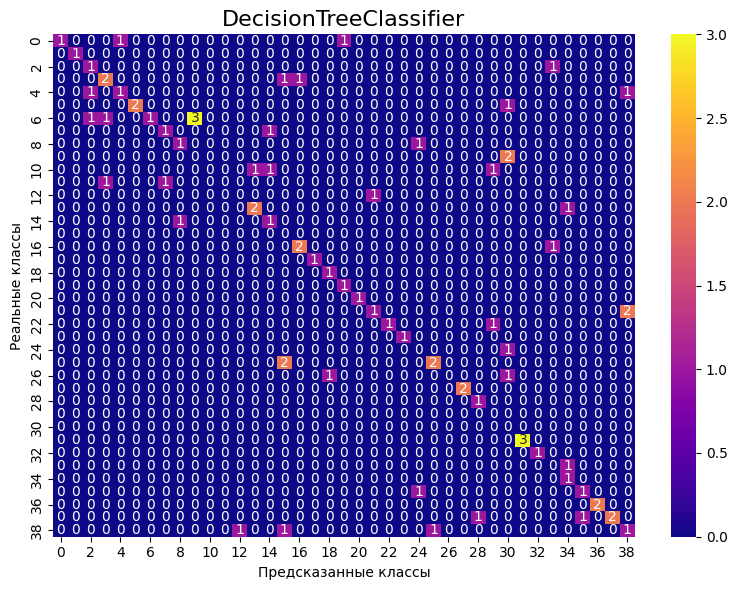

Модель: GaussianNB
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2
           3       1.00      1.00      1.00         4
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           7       0.00      0.00      0.00         6
           8       1.00      1.00      1.00         2
           9       0.29      1.00      0.44         2
          10       1.00      0.50      0.67         2
          11       1.00      0.67      0.80         3
          12       0.50      0.50      0.50         2
          13       1.00      1.00      1.00         1
          14       1.00      1.00      1.00         3
          15       0.50      1.00      0.67         2
          16       0.00      0.00      0.00         0
          17       1.00      0.33      0.50    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

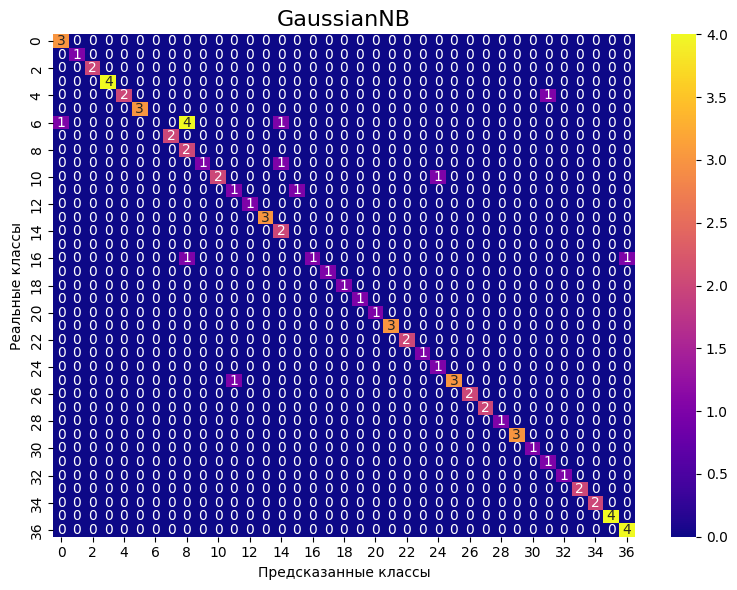

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

models3 = [('LogisticRegression', Lr), ('KNN', Knn),
 ('DecisionTreeClassifier', Dt), ('GaussianNB', Nb)]

for name, model in models3:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Модель: {name}")
    print(f"Accuracy: {acc:.2f}")
    print(classification_report(y_test, y_pred))
    cm3 = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm3,
                annot=True,
                fmt='d',
                cmap='plasma',
                )
    plt.title(str(name), fontsize=16)
    plt.xlabel('Предсказанные классы')
    plt.ylabel('Реальные классы')
    plt.tight_layout()
    plt.show()